# 02 — Experiments: ADJSCC vs DeepJSCC baseline

Reproduces the paper's core claim: one attention model (ADJSCC) matches or beats
fixed-SNR baselines across the whole SNR range, and is robust to channel mismatch.

Run these first (GPU):
```
python train.py --cond af --ratio 0.1667 --out ckpt/adjscc_r16.pt
python train.py --snr-fixed 1  --ratio 0.1667 --out ckpt/base_snr1.pt
python train.py --snr-fixed 19 --ratio 0.1667 --out ckpt/base_snr19.pt
python eval.py --ckpt ckpt/adjscc_r16.pt --cond af --out results/adjscc.csv --dump-samples 8
python eval.py --ckpt ckpt/base_snr1.pt  --out results/base_snr1.csv
python eval.py --ckpt ckpt/base_snr19.pt --out results/base_snr19.csv
```

In [1]:
import glob, csv, matplotlib.pyplot as plt
def load(path):
    xs, ps = [], []
    with open(path) as f:
        for r in csv.DictReader(f):
            xs.append(float(r['snr'])); ps.append(float(r['psnr']))
    return xs, ps
for p in sorted(glob.glob('../results/*.csv')): print(p)

## PSNR vs test SNR
ADJSCC single curve vs baselines trained at one SNR. Baselines peak near their train SNR and fall off (mismatch); ADJSCC tracks the envelope.

/var/folders/m7/x79pvj7n0mxdf4v8ky2kds6h0000gn/T/ipykernel_51938/840308443.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.grid(alpha=.3); plt.legend();


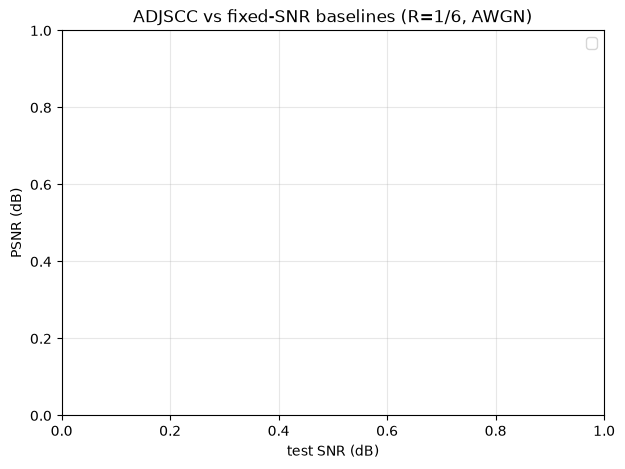

In [2]:
plt.figure(figsize=(7,5))
for p in sorted(glob.glob('../results/*.csv')):
    xs, ps = load(p); name = p.split('/')[-1].replace('.csv','')
    style = '-o' if 'adjscc' in name else '--x'
    plt.plot(xs, ps, style, label=name)
plt.xlabel('test SNR (dB)'); plt.ylabel('PSNR (dB)')
plt.title('ADJSCC vs fixed-SNR baselines (R=1/6, AWGN)')
plt.grid(alpha=.3); plt.legend();

## Mismatch gap
Difference ADJSCC − baseline at each SNR quantifies what attention buys under channel mismatch.

In [3]:
import os
adj = '../results/adjscc.csv'
if os.path.exists(adj):
    ax, ap = load(adj)
    for p in sorted(glob.glob('../results/base_*.csv')):
        bx, bp = load(p)
        gap = [a-b for a,b in zip(ap, bp)]
        plt.plot(ax, gap, '-o', label='vs '+p.split('/')[-1])
    plt.axhline(0, color='k', lw=.5); plt.xlabel('SNR (dB)')
    plt.ylabel('PSNR gain (dB)'); plt.title('ADJSCC advantage over baselines')
    plt.grid(alpha=.3); plt.legend();

## Bandwidth-ratio sweep (optional)
Retrain ADJSCC at other ratios (`--ratio 0.0833`, `0.3333`) and eval; overlay curves to see the compression/quality tradeoff.